## Tableau - Plotly Express
- Plotly is much closer to Tableau
    * Hover tooltips
    * Interactive zooming
    * Sorting
    * Filtering support
    * Value labels on bars
    * Dashboard integration

In [6]:
# Libraries
import pandas as pd
import plotly.express as px

In [7]:
csv_orders_url = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
orders = pd.read_csv(csv_orders_url)
orders.shape

(9994, 21)

In [8]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
selc1 = ['Region', 'State','Customer Name','Sales']
orders[selc1].head()
orders1 = orders[selc1].copy()
orders1.head()

,Region,State,Customer Name,Sales
0,South,Kentucky,Claire Gute,261.9600
1,South,Kentucky,Claire Gute,731.9400
2,West,California,Darrin Van Huff,14.6200
3,South,Florida,Sean O'Donnell,957.5775
4,South,Florida,Sean O'Donnell,22.3680


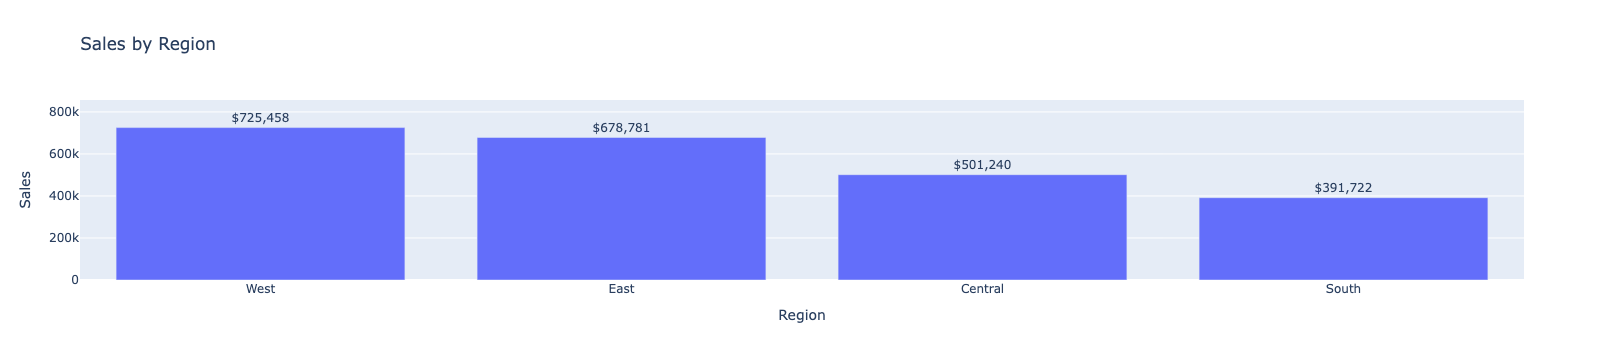

In [10]:
# Plot1 : Sales by Region
region_sales = (  orders1.groupby("Region")["Sales"].sum()
      .reset_index().sort_values("Sales", ascending=False))
fig = px.bar( region_sales, x="Region", y="Sales", text="Sales", title="Sales by Region"
)
fig.update_traces( texttemplate='$%{text:,.0f}',textposition='outside')
fig.update_layout( yaxis_title="Sales",xaxis_title="Region")
fig.show();

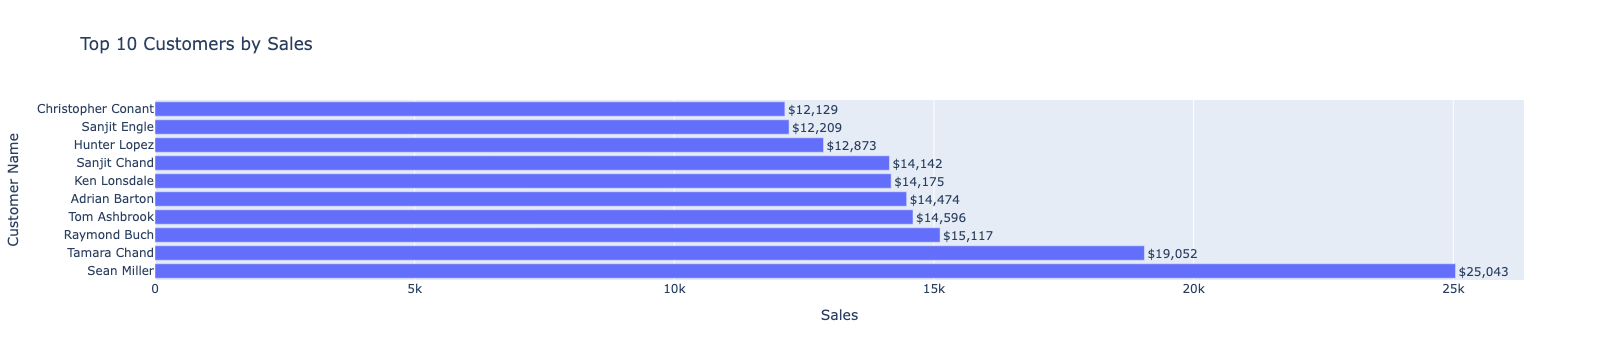

In [11]:
#Plot-2 : Top 10 Customers By Sales
top_customers = (orders1.groupby("Customer Name")["Sales"].sum()
      .reset_index().sort_values("Sales", ascending=False).head(10))
fig = px.bar(top_customers, x="Sales", y="Customer Name", orientation="h",text="Sales",
    title="Top 10 Customers by Sales")
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.show();

In [12]:
orders1["Customer Total Sales"] = ( orders1.groupby("Customer Name")["Sales"]
.transform("sum"))
orders1.head()

,Region,State,Customer Name,Sales,Customer Total Sales
0,South,Kentucky,Claire Gute,261.9600,1148.7800
1,South,Kentucky,Claire Gute,731.9400,1148.7800
2,West,California,Darrin Van Huff,14.6200,1119.4830
3,South,Florida,Sean O'Donnell,957.5775,2602.5755
4,South,Florida,Sean O'Donnell,22.3680,2602.5755


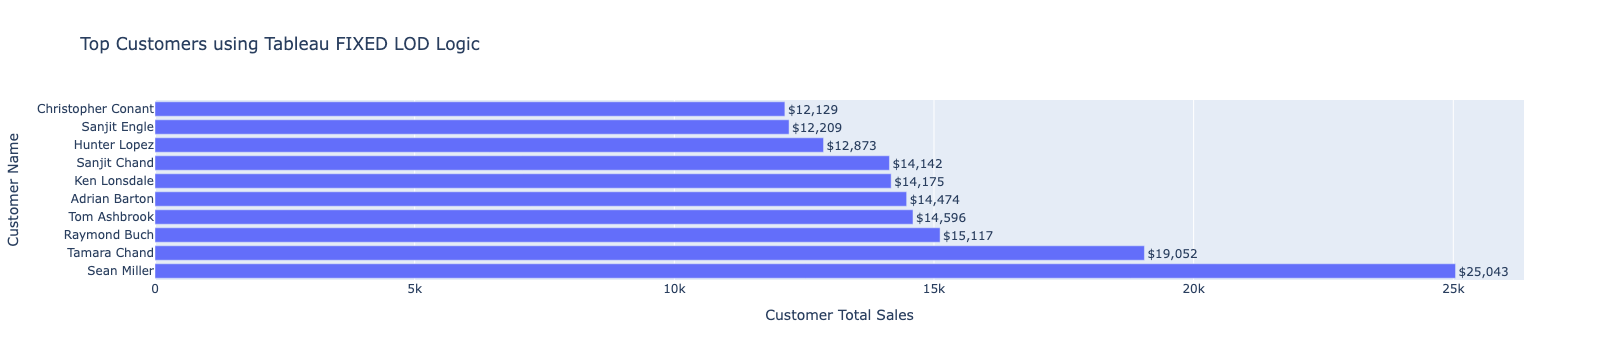

In [13]:
## Plot - 2 : Tableau Fixed LOD eg
lod_sales = (orders1[["Customer Name", "Customer Total Sales"]].drop_duplicates()
      .sort_values("Customer Total Sales", ascending=False ).head(10))
fig = px.bar( lod_sales,  x="Customer Total Sales", y="Customer Name", orientation="h",
    text="Customer Total Sales",  title="Top Customers using Tableau FIXED LOD Logic"
)
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.show();

## Drop Duplicates
- as there may more than 1 row for each Customer - Total Sales 

In [14]:
## Plot 4 : Sales by Region - Customer
region_customer = (orders1.groupby(["Region", "Customer Name"])["Sales"]
    .sum().reset_index())
region_customer.sort_values(['Customer Name','Region']).reset_index()

,index,Region,Customer Name,Sales
0,0,Central,Aaron Bergman,576.564
1,1815,West,Aaron Bergman,309.592
2,629,East,Aaron Hawkins,330.126
3,1303,South,Aaron Hawkins,86.450
4,1816,West,Aaron Hawkins,1328.124
...,...,...,...,...
2496,1813,South,Zuschuss Carroll,1470.892
2497,2499,West,Zuschuss Carroll,2641.089
2498,628,Central,Zuschuss Donatelli,331.080
2499,1814,South,Zuschuss Donatelli,856.664


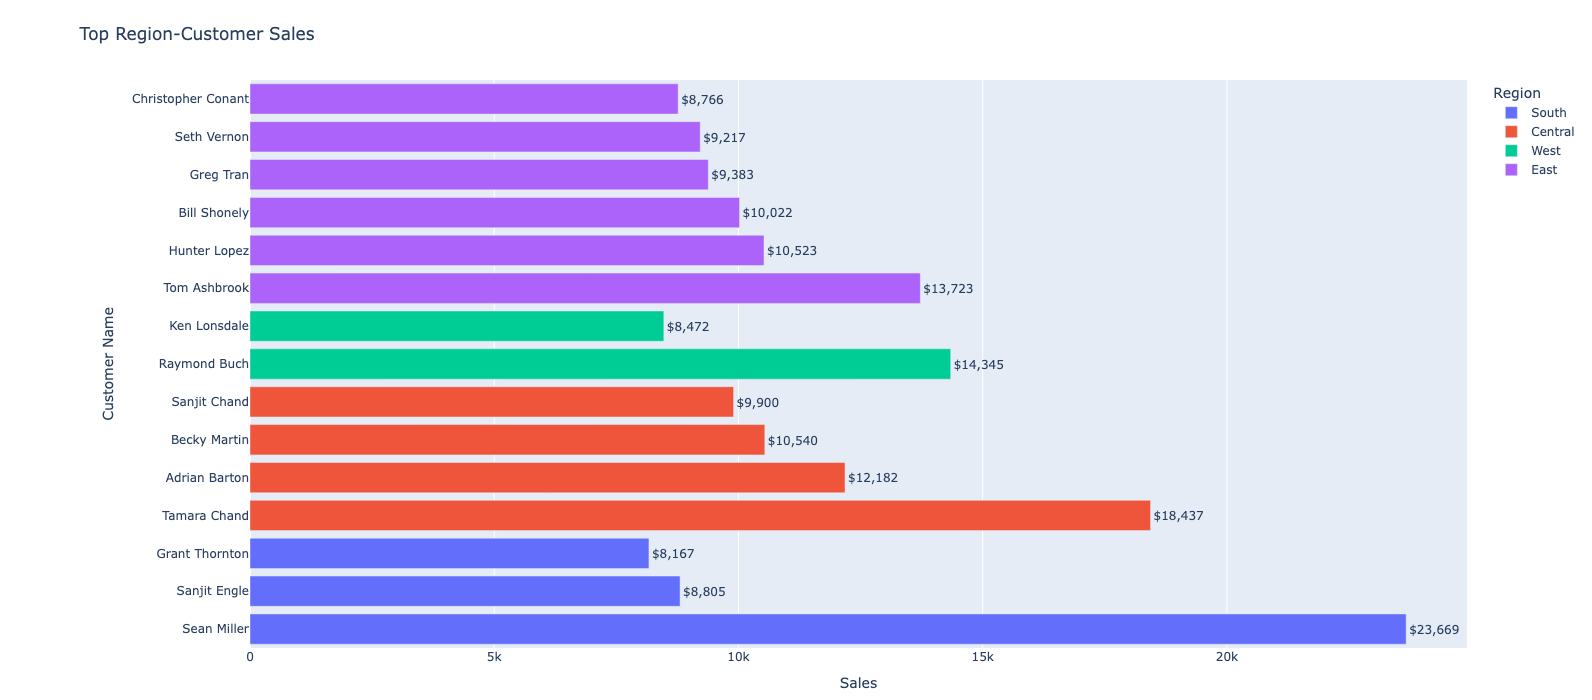

In [15]:
top15 = (region_customer.sort_values("Sales", ascending=False)
.head(15))
fig = px.bar( top15,  x="Sales",   y="Customer Name",  color="Region",  orientation="h",
    text="Sales",   title="Top Region-Customer Sales")
fig.update_traces(   texttemplate='$%{text:,.0f}',   textposition='outside')
fig.update_layout(   width=1200,   height=700, margin=dict(l=250, r=100, t=80, b=50))
fig.show();

# Comparison : Tableau - Plotly
- Tableau Chart : Plotly
- Sales by Region : px.bar()
- Sales Trend by Month : px.line()
- Profit vs Sales Scatter : px.scatter()
- Category Share : px.pie()
- State Map : px.choropleth()
- Customer LOD Analysis :  groupby().transform() + px.bar() :
- Interactive Dashboard : Dash + Plotly

# other options
- Bars Thicker : fig.update_layout(   bargap=0.15)
- Larger fonts :
  - fig.update_layout(  title_font_size=24,   font=dict(size=16), axis_title_font_size=18,
    yaxis_title_font_size=18)
- Tableau style template
    - fig.update_layout( template="plotly_white", width=1400, height=800,
    margin=dict(l=250, r=80, t=80, b=60),   font=dict(size=16))
- My setting
    - fig.update_layout( template="plotly_white", width=1400,  height=800,  margin= dict(l=250, r=80, t=80, b=60),   font=dict(size=16),   bargap=0.15) 